# 🍽️ Zomato Restaurant Analysis — Enhanced
> **Objective:** Uncover patterns in restaurant ratings, costs, ordering behaviour, and popularity using structured EDA and clear visualisations.


## 1 · Imports & Global Style

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display


# ── Global aesthetics ──────────────────────────────────────────────────────
PALETTE  = "viridis"
BG       = "#F9F9F9"
ACCENT   = "#E63946"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
})
print("Libraries loaded.")


Libraries loaded.


## 2 · Load Data

In [19]:
df_raw = pd.read_csv('Zomato-data.csv')
print(f"Shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print("\nFirst 5 rows:")
df_raw.head()


Shape : 148 rows × 7 columns

First 5 rows:


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## 3 · Initial Exploration

In [20]:
print("── Column Types ──────────────────────")
print(df_raw.dtypes)

print("\n── Missing Values ───────────────────")
print(df_raw.isnull().sum())

print("\n── Duplicates ────────────────────────")
print(f"{df_raw.duplicated().sum()} duplicate rows")


── Column Types ──────────────────────
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
approx_cost(for two people)    int64
listed_in(type)                  str
dtype: object

── Missing Values ───────────────────
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

── Duplicates ────────────────────────
0 duplicate rows


## 4 · Data Cleaning
Key issues found:
- `rate` is stored as strings like `"4.1/5"`, `"3.8 /5"`, `"NEW"`, `"-"`
- `approx_cost` sometimes contains commas (`"1,200"`)
- Column name `listed_in(type)` and `approx_cost(for two people)` need aliases


In [21]:
df = df_raw.copy()

# ── Rename for convenience ─────────────────────────────────────────────────
df.rename(columns={
    'listed_in(type)':              'rest_type',
    'approx_cost(for two people)':  'cost_for_two'
}, inplace=True)

# ── Clean `rate` ───────────────────────────────────────────────────────────
def parse_rate(val):
    val = str(val).strip().replace(' ', '')
    if val in ('NEW', '-', 'nan', ''):
        return np.nan
    try:
        return float(val.split('/')[0])
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(parse_rate)
median_rate = df['rate'].median()
df['rate'].fillna(median_rate, inplace=True)
print(f"Ratings — min: {df['rate'].min()}, max: {df['rate'].max()}, "
      f"median: {median_rate:.2f}, nulls filled: {df_raw['rate'].apply(parse_rate).isna().sum()}")

# ── Clean `cost_for_two` ───────────────────────────────────────────────────
df['cost_for_two'] = (
    df['cost_for_two'].astype(str)
    .str.replace(',', '', regex=False)
)
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')
print(f"Costs  — min: ₹{df['cost_for_two'].min():.0f}, "
      f"max: ₹{df['cost_for_two'].max():.0f}")

# ── Boolean flags ─────────────────────────────────────────────────────────
df['online_order_bool'] = df['online_order'].map({'Yes': True, 'No': False})
df['book_table_bool']   = df['book_table'].map({'Yes': True, 'No': False})

# ── Derived features ──────────────────────────────────────────────────────
df['rating_band'] = pd.cut(
    df['rate'],
    bins=[0, 3.0, 3.5, 4.0, 4.5, 5.0],
    labels=['Poor (<3)', 'Average (3–3.5)', 'Good (3.5–4)',
            'Very Good (4–4.5)', 'Excellent (4.5+)'],
    right=True
)
df['cost_segment'] = pd.cut(
    df['cost_for_two'],
    bins=[0, 300, 600, 900, np.inf],
    labels=['Budget (≤300)', 'Mid-range (301–600)',
            'Premium (601–900)', 'Luxury (900+)']
)

print("\nCleaning complete. Shape:", df.shape)
df.head()


Ratings — min: 2.6, max: 4.6, median: 3.70, nulls filled: 0
Costs  — min: ₹100, max: ₹950

Cleaning complete. Shape: (148, 11)


,name,online_order,book_table,rate,votes,cost_for_two,rest_type,online_order_bool,book_table_bool,rating_band,cost_segment
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,True,True,Very Good (4–4.5),Premium (601–900)
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,True,False,Very Good (4–4.5),Premium (601–900)
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,True,False,Good (3.5–4),Premium (601–900)
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,False,False,Good (3.5–4),Budget (≤300)
4,Grand Village,No,No,3.8,166,600,Buffet,False,False,Good (3.5–4),Mid-range (301–600)


## 5 · Statistical Summary

In [22]:
display(df[['rate', 'votes', 'cost_for_two']].describe().round(2))


,rate,votes,cost_for_two
count,148.00,148.00,148.00
mean,3.63,264.81,418.24
std,0.40,653.68,223.09
min,2.60,0.00,100.00
25%,3.30,6.75,200.00
50%,3.70,43.50,400.00
75%,3.90,221.75,600.00
max,4.60,4884.00,950.00


## 6 · Distribution Overview

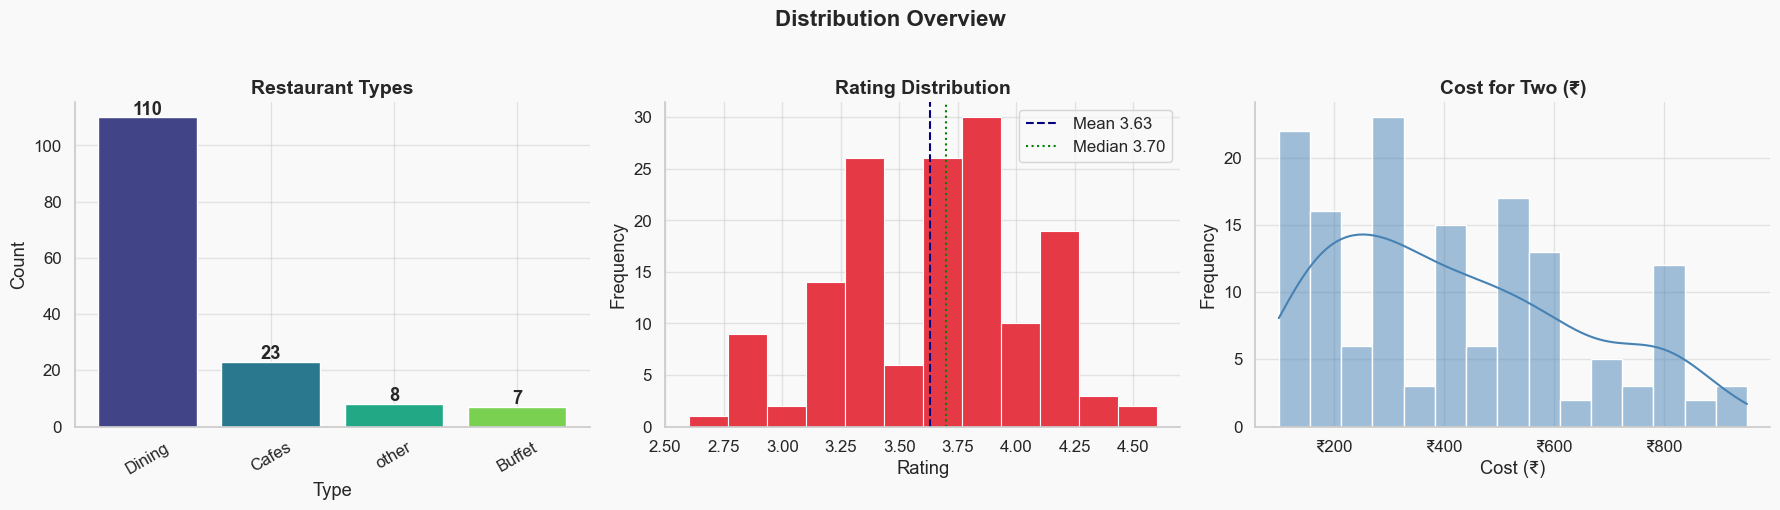

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution Overview", fontsize=16, fontweight='bold', y=1.02)

# 6a — Restaurant type
type_counts = df['rest_type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,color=sns.color_palette(PALETTE, len(type_counts)))
axes[0].set_title("Restaurant Types")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 6b — Rating distribution
axes[1].hist(df['rate'], bins=12, color=ACCENT, edgecolor='white', linewidth=0.8)
axes[1].axvline(df['rate'].mean(),   color='navy',  linestyle='--', label=f"Mean {df['rate'].mean():.2f}")
axes[1].axvline(df['rate'].median(), color='green', linestyle=':',  label=f"Median {df['rate'].median():.2f}")
axes[1].set_title("Rating Distribution")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# 6c — Cost distribution with KDE
sns.histplot(df['cost_for_two'].dropna(), bins=15, kde=True,color='steelblue', ax=axes[2])
axes[2].set_title("Cost for Two (₹)")
axes[2].set_xlabel("Cost (₹)")
axes[2].set_ylabel("Frequency")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x)}"))

plt.tight_layout()
plt.show()


## 7 · Online Order & Table Booking Analysis

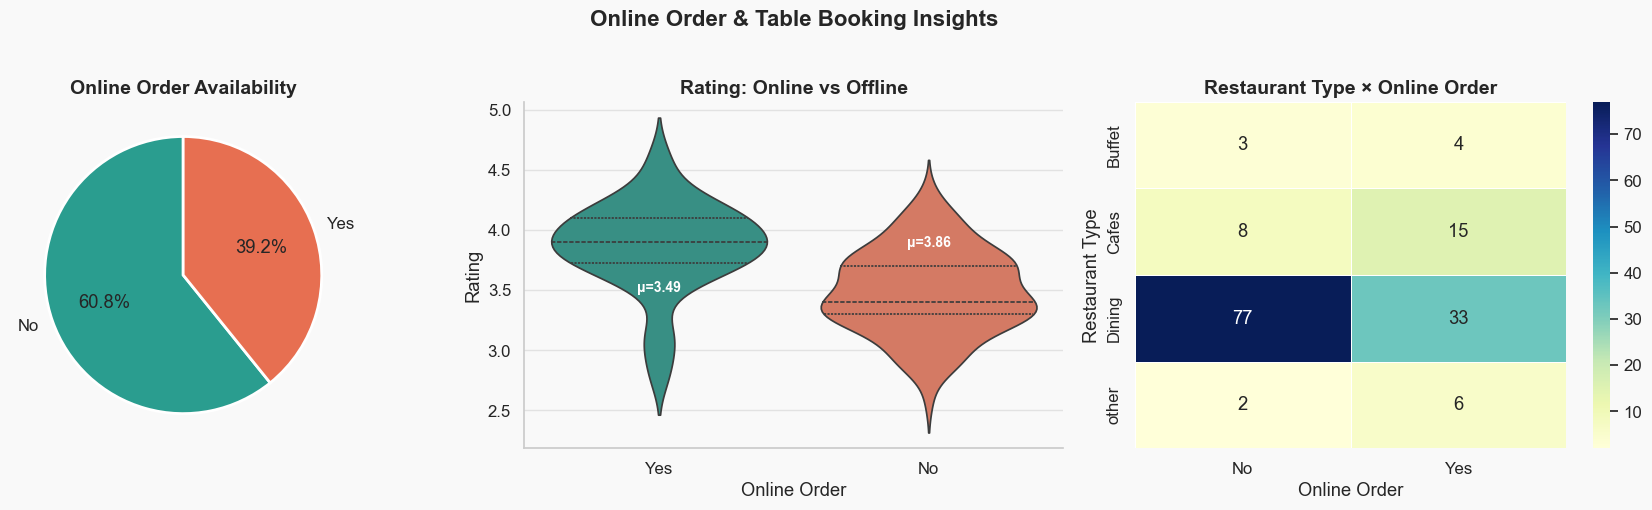

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Online Order & Table Booking Insights", fontsize=16,fontweight='bold', y=1.02)

# 7a — Online order share (pie)
oo_counts = df['online_order'].value_counts()
colors = ['#2A9D8F', '#E76F51']
axes[0].pie(oo_counts.values, labels=oo_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title("Online Order Availability")

# 7b — Rating by online order (violin)
sns.violinplot(data=df, x='online_order', y='rate', hue='online_order',
               palette={'Yes': '#2A9D8F', 'No': '#E76F51'},
               inner='quartile', ax=axes[1], legend=False)
axes[1].set_title("Rating: Online vs Offline")
axes[1].set_xlabel("Online Order")
axes[1].set_ylabel("Rating")
for cat, grp in df.groupby('online_order')['rate']:
    axes[1].annotate(f"μ={grp.mean():.2f}", xy=(0 if cat=='No' else 1, grp.mean()),
                     ha='center', color='white', fontweight='bold', fontsize=10)

# 7c — Heatmap: type × online_order
pivot = pd.pivot_table(df, index='rest_type', columns='online_order',aggfunc='size', fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu',linewidths=0.5, ax=axes[2])

axes[2].set_title("Restaurant Type × Online Order")
axes[2].set_xlabel("Online Order")
axes[2].set_ylabel("Restaurant Type")

plt.tight_layout()
plt.show()


## 8 · Rating Bands & Cost Segments

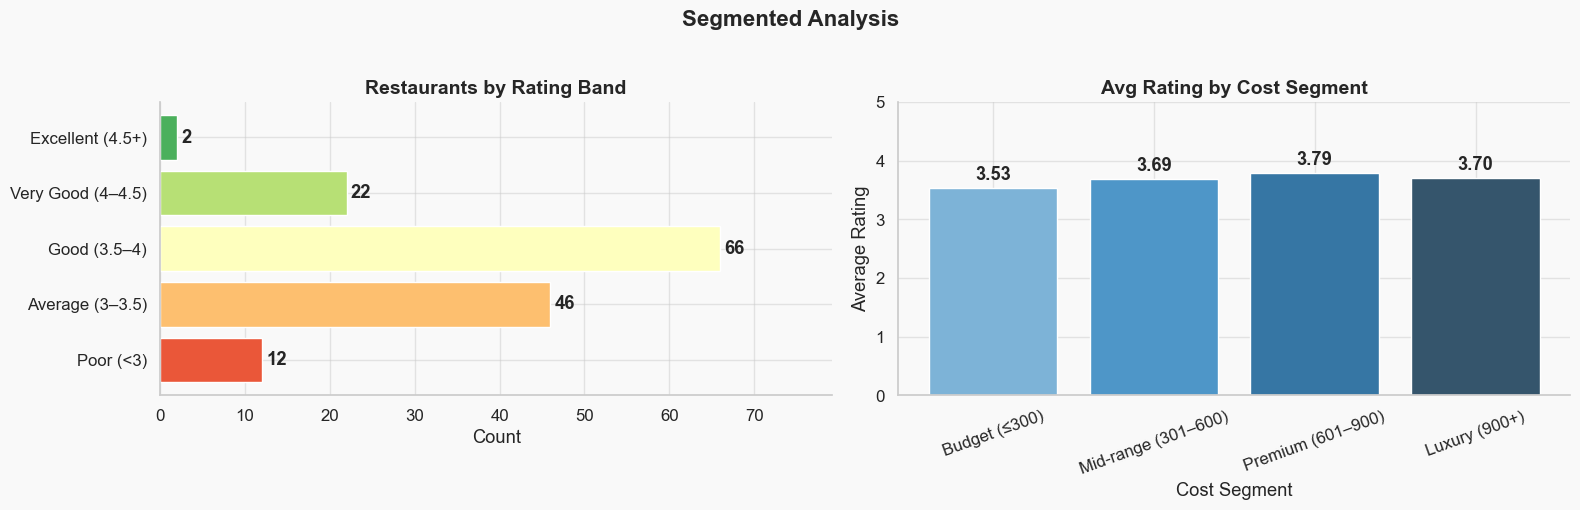

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Segmented Analysis", fontsize=16, fontweight='bold', y=1.02)

# 8a — Rating band counts
rb_counts = df['rating_band'].value_counts().sort_index()
bars = axes[0].barh(rb_counts.index.astype(str), rb_counts.values,
                    color=sns.color_palette("RdYlGn", len(rb_counts)))
axes[0].set_title("Restaurants by Rating Band")
axes[0].set_xlabel("Count")
axes[0].bar_label(bars, padding=3, fontweight='bold')
axes[0].set_xlim(0, rb_counts.max() * 1.2)

# 8b — Avg rating per cost segment
cs_avg = df.groupby('cost_segment', observed=True)['rate'].mean().sort_index()
bars2 = axes[1].bar(cs_avg.index.astype(str), cs_avg.values,color=sns.color_palette("Blues_d", len(cs_avg)))
axes[1].set_title("Avg Rating by Cost Segment")
axes[1].set_xlabel("Cost Segment")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=20)
axes[1].bar_label(bars2, fmt='%.2f', padding=3, fontweight='bold')

plt.tight_layout()
plt.show()


## 9 · Popularity (Votes) Analysis

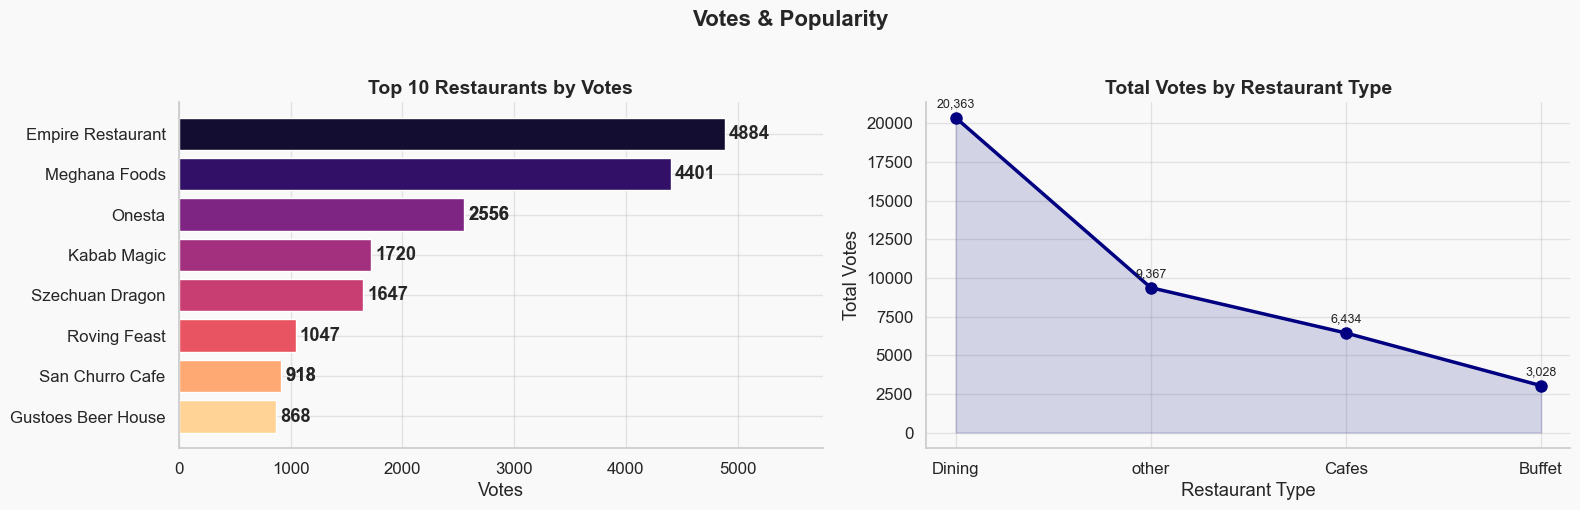

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Votes & Popularity", fontsize=16, fontweight='bold', y=1.02)

# 9a — Top 10 restaurants by votes
top10 = (df[['name', 'votes', 'rest_type']]
         .sort_values('votes', ascending=False)
         .head(10))
colors = sns.color_palette('magma', 10)
bars = axes[0].barh(top10['name'], top10['votes'], color=colors)
axes[0].set_title("Top 10 Restaurants by Votes")
axes[0].set_xlabel("Votes")
axes[0].invert_yaxis()
axes[0].bar_label(bars, padding=3, fontweight='bold')
axes[0].set_xlim(0, top10['votes'].max() * 1.18)

# 9b — Total votes by restaurant type (line + scatter)
vt = df.groupby('rest_type')['votes'].sum().sort_values(ascending=False)
axes[1].plot(vt.index, vt.values, marker='o', linewidth=2.5,markersize=8, color='navy')
axes[1].fill_between(vt.index, vt.values, alpha=0.15, color='navy')
axes[1].set_title("Total Votes by Restaurant Type")
axes[1].set_xlabel("Restaurant Type")
axes[1].set_ylabel("Total Votes")
for x, y in zip(vt.index, vt.values):
    axes[1].annotate(f"{y:,}", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 10 · Correlation & Scatter Analysis

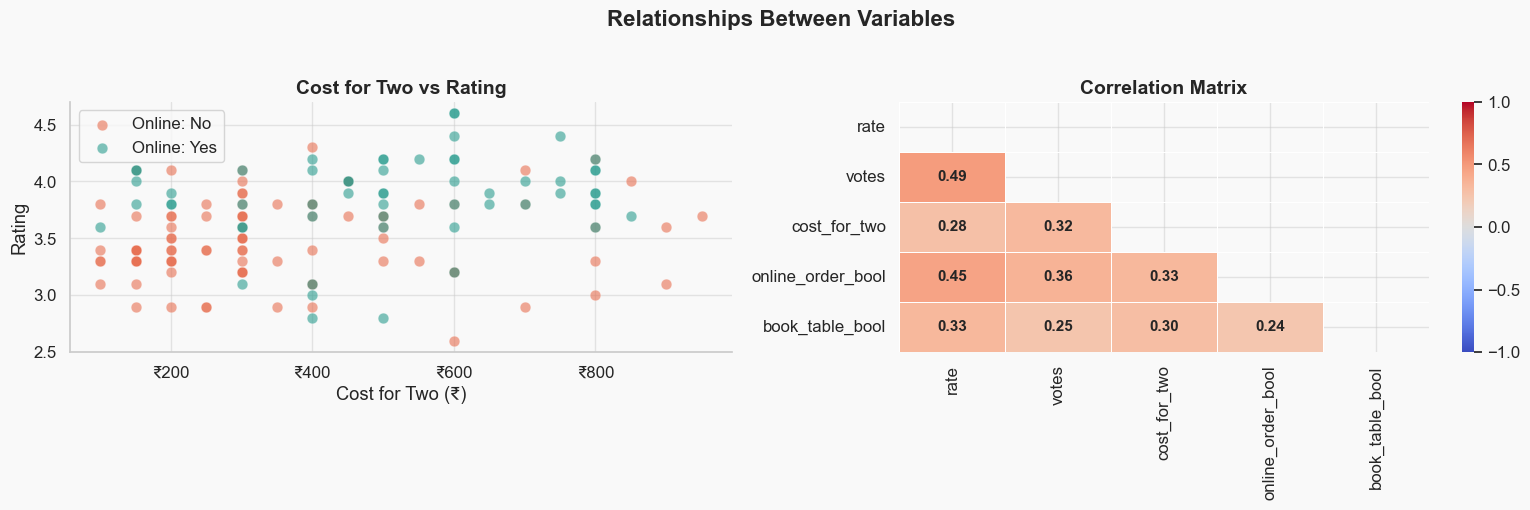

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Relationships Between Variables", fontsize=16, fontweight='bold', y=1.02)

# 10a — Scatter: Cost vs Rating (coloured by online_order)
for label, grp in df.groupby('online_order'):
    axes[0].scatter(grp['cost_for_two'], grp['rate'], alpha=0.6,
                    label=f"Online: {label}",
                    color='#2A9D8F' if label == 'Yes' else '#E76F51',
                    edgecolors='white', linewidths=0.4, s=60)
axes[0].set_title("Cost for Two vs Rating")
axes[0].set_xlabel("Cost for Two (₹)")
axes[0].set_ylabel("Rating")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x)}"))

# 10b — Correlation heatmap (numeric cols)
num_cols = ['rate', 'votes', 'cost_for_two', 'online_order_bool', 'book_table_bool']
corr = df[num_cols].astype(float).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()


## 11 · Restaurant Type — Aggregated Summary

In [28]:
summary = (
    df.groupby('rest_type')
    .agg(
        Count        = ('name',          'count'),
        Avg_Rating   = ('rate',          'mean'),
        Avg_Cost     = ('cost_for_two',  'mean'),
        Total_Votes  = ('votes',         'sum'),
        Pct_Online   = ('online_order_bool', lambda x: f"{x.mean()*100:.0f}%")
    )
    .sort_values('Total_Votes', ascending=False)
    .round(2)
)
print(summary.to_string())


           Count  Avg_Rating  Avg_Cost  Total_Votes Pct_Online
rest_type                                                     
Dining       110        3.57    357.27        20363        30%
other          8        3.91    668.75         9367        75%
Cafes         23        3.77    545.65         6434        65%
Buffet         7        3.84    671.43         3028        57%


## 12 · Table Booking Impact

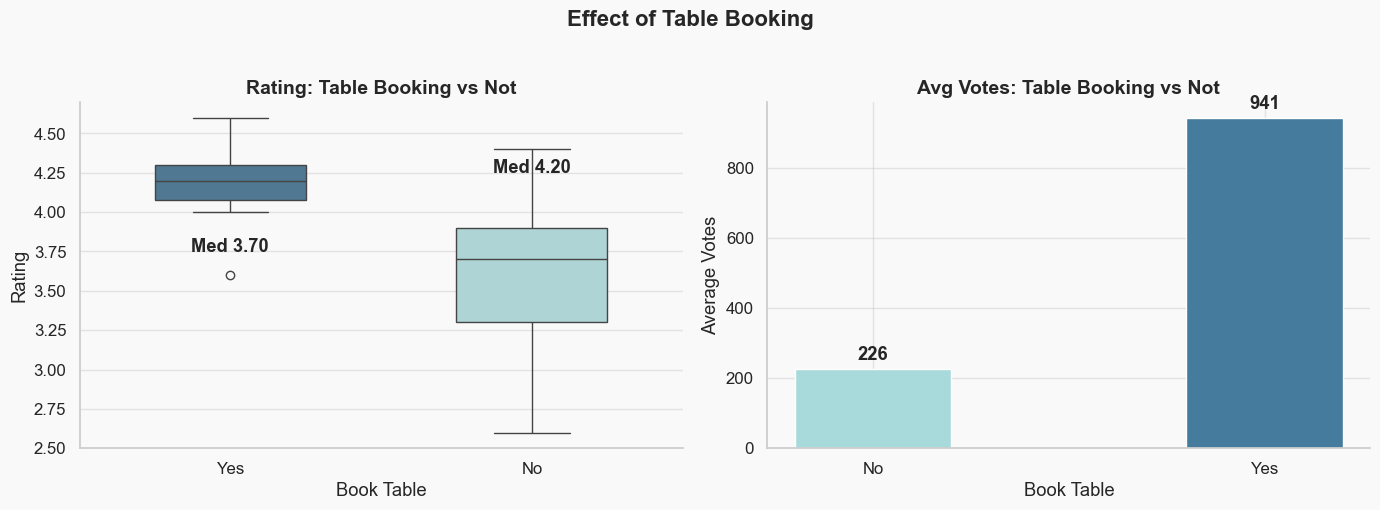

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of Table Booking", fontsize=16, fontweight='bold', y=1.02)

bt_palette = {'Yes': '#457B9D', 'No': '#A8DADC'}

# 12a — Rating by book_table
sns.boxplot(data=df, x='book_table', y='rate', hue='book_table',
            palette=bt_palette, width=0.5, ax=axes[0], legend=False)
axes[0].set_title("Rating: Table Booking vs Not")
axes[0].set_xlabel("Book Table")
axes[0].set_ylabel("Rating")
for i, (cat, grp) in enumerate(df.groupby('book_table')['rate']):
    axes[0].text(i, grp.median() + 0.05, f"Med {grp.median():.2f}",
                 ha='center', fontweight='bold')

# 12b — Avg votes by book_table
bt_votes = df.groupby('book_table')['votes'].mean()
bars = axes[1].bar(bt_votes.index, bt_votes.values,
                   color=[bt_palette[k] for k in bt_votes.index], width=0.4)
axes[1].set_title("Avg Votes: Table Booking vs Not")
axes[1].set_xlabel("Book Table")
axes[1].set_ylabel("Average Votes")
axes[1].bar_label(bars, fmt='%.0f', padding=4, fontweight='bold')

plt.tight_layout()
plt.show()


## 13 · Final Insights

In [31]:
pct_online = df['online_order_bool'].mean() * 100
avg_rating_online  = df.loc[df['online_order']=='Yes', 'rate'].mean()
avg_rating_offline = df.loc[df['online_order']=='No',  'rate'].mean()
most_common_type   = df['rest_type'].mode()[0]
top_restaurant     = df.loc[df['votes'].idxmax(), 'name']
corr_cost_rating   = df[['cost_for_two','rate']].corr().iloc[0,1]
corr_votes_rating  = df[['votes','rate']].corr().iloc[0,1]

insights = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    KEY FINDINGS SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║  📊 Dataset       : {df.shape[0]} restaurants, {df.shape[1]} features            ║
║  🍽️  Most Common  : {most_common_type} ({df['rest_type'].value_counts().iloc[0]} restaurants)                ║
║  🏆 Most Popular  : {top_restaurant[:35]:<35} ║
║  📱 Online Orders : {pct_online:.0f}% of restaurants offer online ordering     ║
║  ⭐ Avg Rating    : Online = {avg_rating_online:.2f}  |  Offline = {avg_rating_offline:.2f}         ║
║  💰 Cost–Rating   : correlation = {corr_cost_rating:+.2f} (slight positive)      ║
║  🗳️  Votes–Rating  : correlation = {corr_votes_rating:+.2f} (slight positive)      ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(insights)



╔══════════════════════════════════════════════════════════════════╗
║                    KEY FINDINGS SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║  📊 Dataset       : 148 restaurants, 11 features            ║
║  🍽️  Most Common  : Dining (110 restaurants)                ║
║  🏆 Most Popular  : Empire Restaurant                   ║
║  📱 Online Orders : 39% of restaurants offer online ordering     ║
║  ⭐ Avg Rating    : Online = 3.86  |  Offline = 3.49         ║
║  💰 Cost–Rating   : correlation = +0.28 (slight positive)      ║
║  🗳️  Votes–Rating  : correlation = +0.49 (slight positive)      ║
╚══════════════════════════════════════════════════════════════════╝

